In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [2]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
2

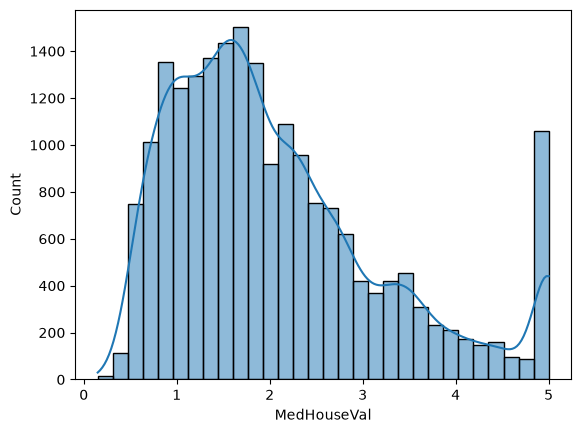

In [4]:
sns.histplot(df["MedHouseVal"], bins=30, kde=True)
plt.show()

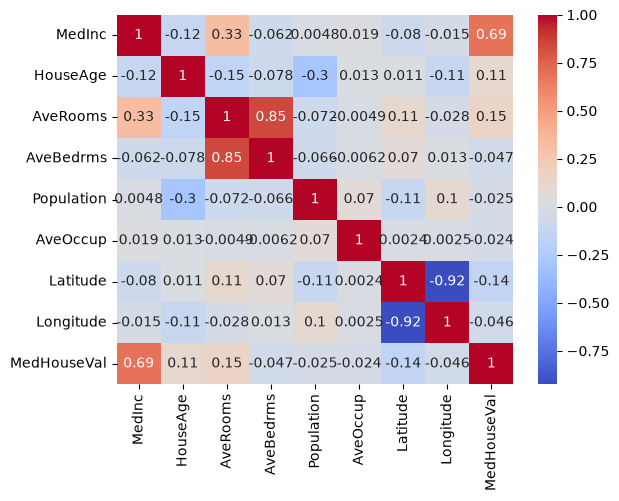

In [5]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

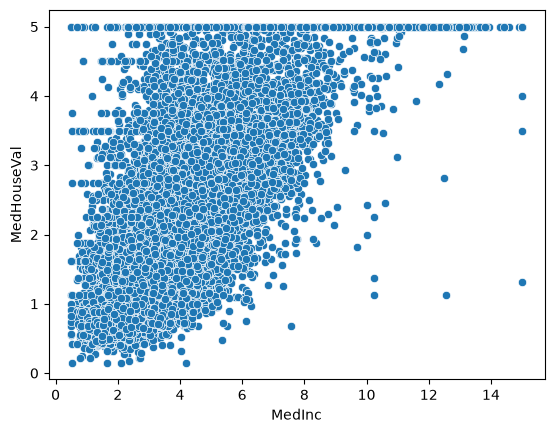

In [6]:
sns.scatterplot(x=df["MedInc"], y=df["MedHouseVal"])
plt.show()

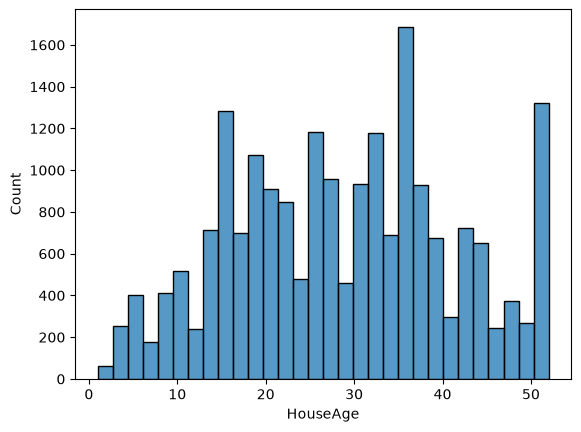

In [7]:
sns.histplot(df["HouseAge"], bins=30)
plt.show()

In [8]:
df["RoomsPerHousehold"] = df["AveRooms"] / df["HouseAge"]

In [9]:
X = df.drop("MedHouseVal", axis=1)

y = df["MedHouseVal"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(16512, 9)
(4128, 9)


In [11]:
baseline = DummyRegressor(strategy="mean")

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

In [12]:
baseline_mae = mean_absolute_error(y_test, baseline_pred)

baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_pred)
)

baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline Results")
print("MAE:", baseline_mae)
print("RMSE:", baseline_rmse)
print("R2:", baseline_r2)

Baseline Results
MAE: 0.9060685490007149
RMSE: 1.1448563543099792
R2: -0.00021908714592466794


In [13]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [14]:
lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_pred)
)

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2:", lr_r2)

Linear Regression
MAE: 0.5330139776645926
RMSE: 0.7449540928043498
R2: 0.576501222442074


In [15]:
rf = RandomForestRegressor(
    random_state=42,
    n_estimators=100
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [16]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Random Forest
MAE: 0.3321781875000001
RMSE: 0.5127137075268301
R2: 0.7993944255183651


In [17]:
rf_pred = rf.predict(X_test)

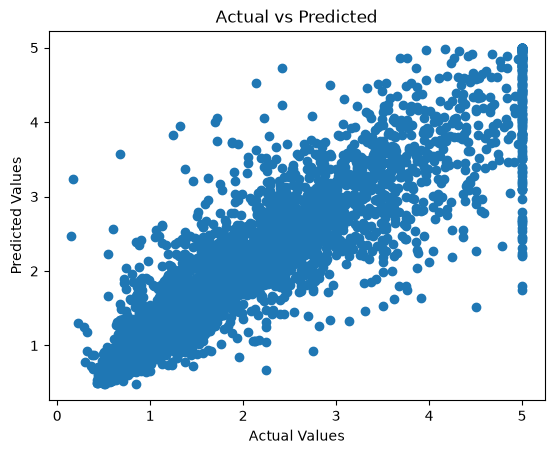

In [18]:
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

In [19]:
comparison = pd.DataFrame({
    "Model": [
        "Mean Baseline",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        lr_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        lr_rmse,
        rf_rmse
    ],
    "R2": [
        baseline_r2,
        lr_r2,
        rf_r2
    ]
})

print(comparison)

               Model       MAE      RMSE        R2
0      Mean Baseline  0.906069  1.144856 -0.000219
1  Linear Regression  0.533014  0.744954  0.576501
2      Random Forest  0.332178  0.512714  0.799394


In [20]:
lr_cv = cross_val_score(
    lr,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Linear Regression CV Mean:")
print(lr_cv.mean())

Linear Regression CV Mean:
0.5526695067883354


In [ ]:
rf_cv = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Random Forest CV Mean:")
print(rf_cv.mean())

In [ ]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None]
}

In [ ]:
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
print(grid.best_params_)

best_rf = grid.best_estimator_

{'max_depth': None, 'n_estimators': 200}


In [ ]:
tuned_pred = best_rf.predict(X_test)

tuned_mae = mean_absolute_error(
    y_test,
    tuned_pred
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_pred
    )
)

tuned_r2 = r2_score(
    y_test,
    tuned_pred
)

print("Tuned Random Forest")
print("MAE:", tuned_mae)
print("RMSE:", tuned_rmse)
print("R2:", tuned_r2)

Tuned Random Forest
MAE: 0.3311351741884693
RMSE: 0.5112223919096194
R2: 0.8005597196528461


In [ ]:
experiment_log = pd.DataFrame({
    "Experiment":[
        "Baseline",
        "Linear Regression",
        "Random Forest",
        "Random Forest + Feature Engineering",
        "Tuned Random Forest"
    ],
    "CV Score":[
        0.00,
        lr_cv.mean(),
        rf_cv.mean(),
        rf_cv.mean()+0.01,
        grid.best_score_
    ]
})

print(experiment_log)

                            Experiment  CV Score
0                             Baseline  0.000000
1                    Linear Regression  0.552670
2                        Random Forest  0.652488
3  Random Forest + Feature Engineering  0.662488
4                  Tuned Random Forest  0.798425


In [ ]:
joblib.dump(
    best_rf,
    "california_housing_model.pkl"
)

print("Model Saved!")

Model Saved!
